# MNIST Classifier Demo
This notebook demonstrates the `MnistClassifier` wrapper with three algorithms:
- `rf` — Random Forest
- `nn` — Feed-Forward Neural Network
- `cnn` — Convolutional Neural Network

Each model is accessed through an identical interface regardless of the algorithm selected.

## 1. Imports & Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from src.data_loader import load_mnist_dataset
from src.classifier import MnistClassifier

## 2. Load Data
Downloads MNIST via `fetch_openml`, normalizes pixel values to `[0, 1]`, and splits into train/test sets.

In [2]:
x_train, x_test, y_train, y_test = load_mnist_dataset(test_size=0.2, random_state=42)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Pixel range: [{x_train.values.min():.3f}, {x_train.values.max():.3f}]")
print(f"Classes: {sorted(y_train.unique())}")

x_train shape: (56000, 784)
x_test shape: (14000, 784)
y_train shape: (56000,)
y_test shape: (14000,)
Pixel range: [0.000, 1.000]
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### Sample images from the dataset

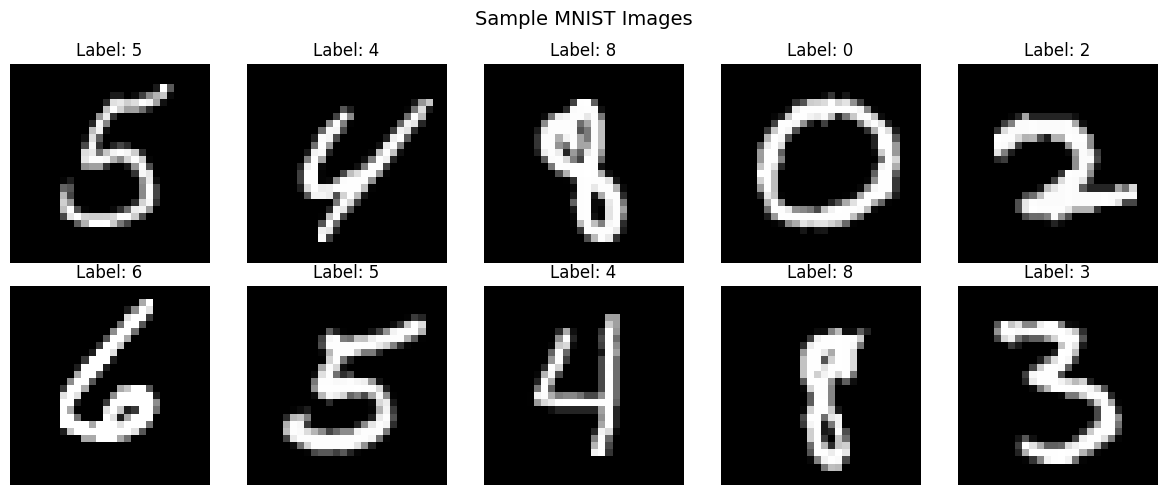

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train.values[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train.values[i]}")
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Helper: Evaluation
Reusable function to print accuracy, classification report, and confusion matrix.

In [4]:
def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"{model_name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=range(10), yticklabels=range(10)
    )
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

## 4. Random Forest (`rf`)


Random Forest — Accuracy: 0.9689 (96.89%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9844    0.9866    0.9855      1343
           1     0.9862    0.9862    0.9862      1600
           2     0.9538    0.9717    0.9627      1380
           3     0.9598    0.9491    0.9544      1433
           4     0.9676    0.9676    0.9676      1295
           5     0.9731    0.9647    0.9688      1273
           6     0.9787    0.9864    0.9825      1396
           7     0.9687    0.9674    0.9680      1503
           8     0.9607    0.9558    0.9583      1357
           9     0.9541    0.9514    0.9528      1420

    accuracy                         0.9689     14000
   macro avg     0.9687    0.9687    0.9687     14000
weighted avg     0.9689    0.9689    0.9688     14000



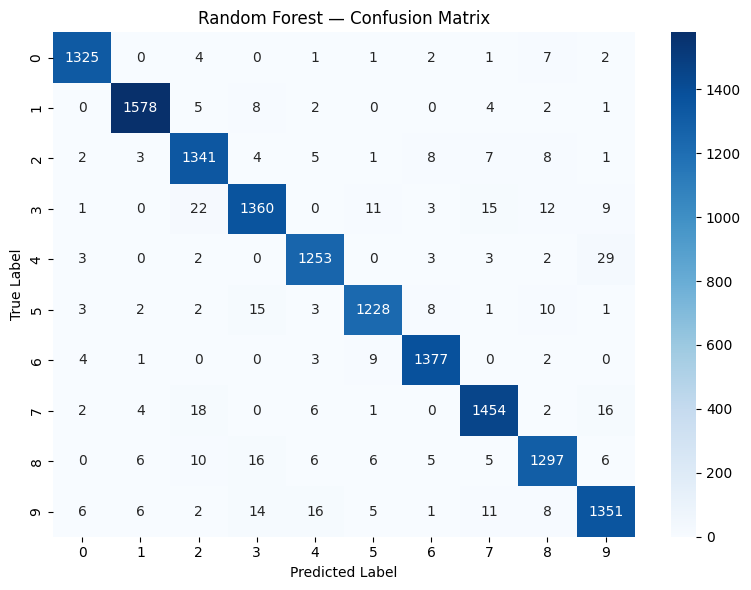

In [5]:
clf_rf = MnistClassifier(algorithm='rf')
clf_rf.train(x_train, y_train)
preds_rf = clf_rf.predict(x_test)
evaluate('Random Forest', y_test, preds_rf)

## 5. Feed-Forward Neural Network (`nn`)

Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:08<00:00, 214.68it/s, loss=0.0863]


Epoch 1/10 | Loss: 0.2855


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:08<00:00, 197.67it/s, loss=0.1866]


Epoch 2/10 | Loss: 0.1264


Epoch 3/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:08<00:00, 199.25it/s, loss=0.1051]


...

Epoch 8/10 | Loss: 0.0464


Epoch 9/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:08<00:00, 202.83it/s, loss=0.0191]


Epoch 9/10 | Loss: 0.0413


Epoch 10/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:08<00:00, 210.34it/s, loss=0.0035]


Epoch 10/10 | Loss: 0.0404

Feed-Forward NN — Accuracy: 0.9806 (98.06%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9831    0.9933    0.9881      1343
           1     0.9870    0.9938    0.9903      1600
           2     0.9700    0.9833    0.9766      1380
           3     0.9837    0.9700    0.9768      1433
           4     0.9726    0.9869    0.9797      1295
           5     0.9811    0.9772    0.9791      1273
           6     0.9914    0.9900    0.9907      1396
           7     0.9681    0.9880    0.9779      1503
           8     0.9863    0.9565    0.9712      1357
           9     0.9828    0.9648    0.9737      1420

    accuracy                         0.9806     14000
   macro avg     0.9806    0.9804    0.9804     14000
weighted avg     0.9806    0.9806    0.9805     14000



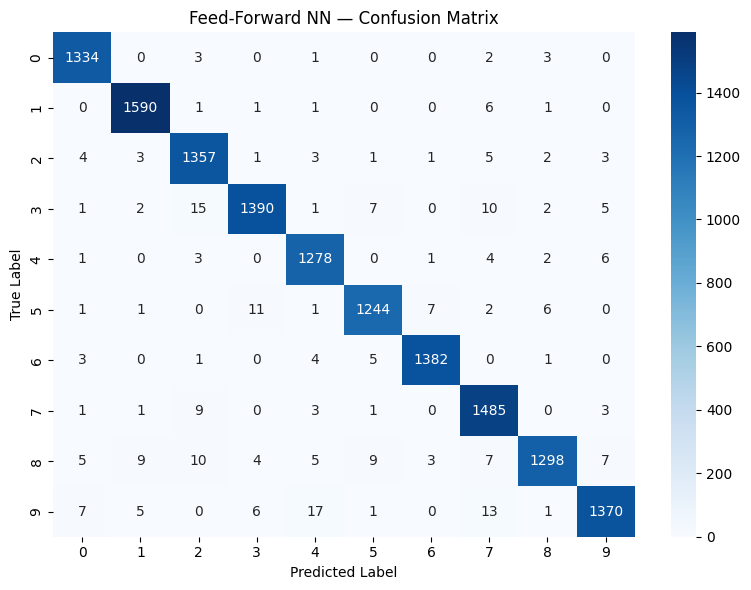

In [6]:
clf_nn = MnistClassifier(algorithm='nn')
clf_nn.train(x_train, y_train)
preds_nn = clf_nn.predict(x_test)
evaluate('Feed-Forward NN', y_test, preds_nn)

## 6. Convolutional Neural Network (`cnn`)

Training | Device: cuda


Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:09<00:00, 178.87it/s, loss=0.1312]


Epoch 1, loss: 0.1767


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:09<00:00, 182.61it/s, loss=0.0118]


Epoch 2, loss: 0.0563


...

Epoch 8, loss: 0.0144


Epoch 9/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:09<00:00, 180.48it/s, loss=0.0635]


Epoch 9, loss: 0.0124


Epoch 10/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:09<00:00, 180.08it/s, loss=0.0777]


Epoch 10, loss: 0.0110

CNN — Accuracy: 0.9909 (99.09%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9985    0.9940    0.9963      1343
           1     0.9950    0.9944    0.9947      1600
           2     0.9942    0.9855    0.9898      1380
           3     0.9909    0.9923    0.9916      1433
           4     0.9839    0.9931    0.9885      1295
           5     0.9937    0.9866    0.9901      1273
           6     0.9929    0.9950    0.9939      1396
           7     0.9887    0.9940    0.9914      1503
           8     0.9875    0.9860    0.9867      1357
           9     0.9839    0.9873    0.9856      1420

    accuracy                         0.9909     14000
   macro avg     0.9909    0.9908    0.9909     14000
weighted avg     0.9909    0.9909    0.9909     14000



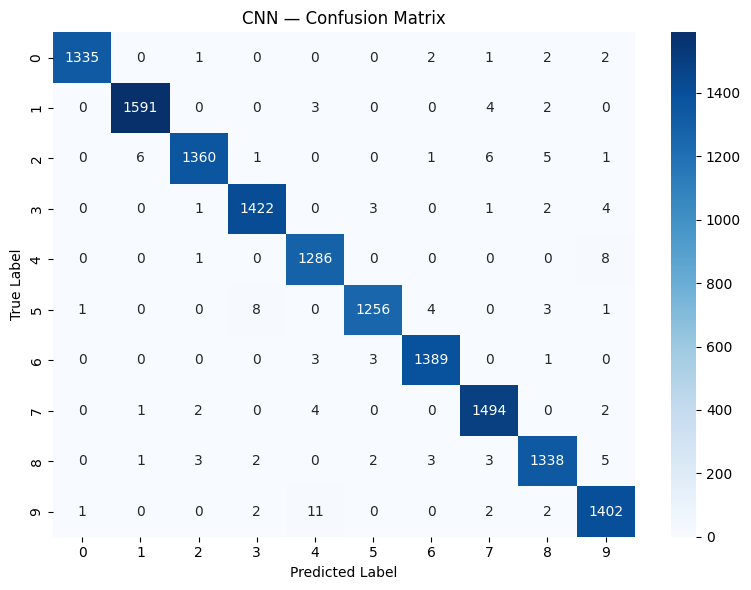

In [7]:
clf_cnn = MnistClassifier(algorithm='cnn')
clf_cnn.train(x_train, y_train)
preds_cnn = clf_cnn.predict(x_test)
evaluate('CNN', y_test, preds_cnn)

## 7. Model Comparison

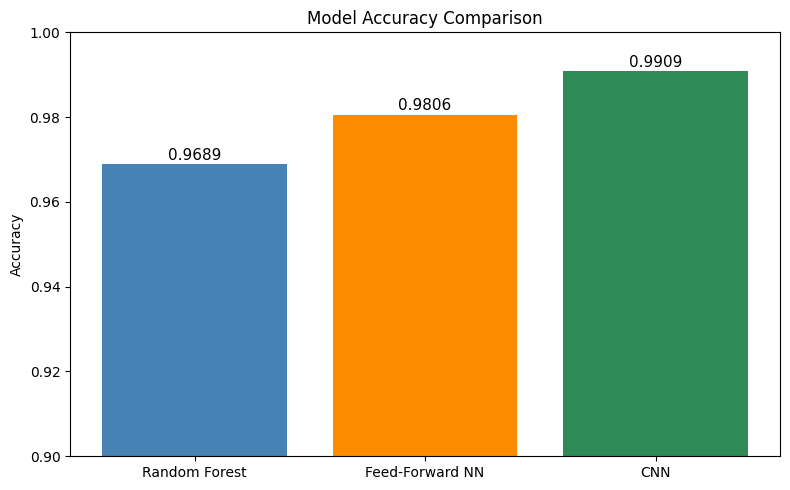

In [8]:
results = {
    'Random Forest': accuracy_score(y_test, preds_rf),
    'Feed-Forward NN': accuracy_score(y_test, preds_nn),
    'CNN': accuracy_score(y_test, preds_cnn),
}

plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['steelblue', 'darkorange', 'seagreen'])
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Edge Cases
The following cells demonstrate how the classifier handles invalid or unexpected inputs.

### 8.1 Invalid algorithm string
Passing an unrecognised algorithm raises a `ValueError` immediately at construction time.

In [9]:
try:
    clf_bad = MnistClassifier(algorithm='svm')
except ValueError as e:
    print(f"ValueError caught: {e}")

ValueError caught: Unknown algorithm: svm. Valid options are: 'rf', 'nn', 'cnn'


### 8.2 Single sample prediction
All three models should handle a single sample `(1, 784)` without errors.

In [11]:
single_sample = x_test.iloc[[0]]  # shape (1, 784)
true_label = y_test.values[0]

for name, clf in [('RF', clf_rf), ('NN', clf_nn), ('CNN', clf_cnn)]:
    pred = clf.predict(single_sample)
    print(f"{name:4s} → predicted: {pred[0]}, true: {true_label}")

RF   → predicted: 8, true: 8
NN   → predicted: 8, true: 8
CNN  → predicted: 8, true: 8
